In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
from pyreadr import read_r
from sklearn.preprocessing import OneHotEncoder

code_dir = Path(os.getcwd())
data_dir = code_dir.parent / "data"

ling_data = pd.read_csv(data_dir / "lingData.txt", sep="\\s+", dtype={"ZIP": str})
ling_location = pd.read_csv(data_dir / "lingLocation.txt", sep="\\s+")
question_data = read_r(data_dir/"question_data.RData")

In [4]:
print(ling_data.head())
# check dtypes
print(ling_data.dtypes)
print(ling_data.shape)
# check for duplicates
print(ling_data['ID'].nunique())


   ID        CITY STATE    ZIP  Q050  Q051  Q052  Q053  Q054  Q055  ...  Q110  \
0   1       Boise    ID  83704     4     1     3     2     3     1  ...     8   
1   2  Pittsfield    MA  01201     4     2     3     2     2     2  ...     8   
2   3  Burlington    VT  05401     4     1     2     2     2     2  ...     4   
3   4      Easton    PA  18042     7     1     1     2     2     2  ...     8   
4   5     Bedford    MA  01730     8     2     3     1     2     2  ...     8   

   Q111  Q115  Q117  Q118  Q119  Q120  Q121        lat        long  
0     2     1     6     7     3     2     3  43.631230 -116.287161  
1     2     1     1     7     1     1     3  42.453840  -73.254003  
2     2     1     4     7     1     2     1  44.484038  -73.221265  
3     1     1     3     7     1     2     1  40.681798  -75.220820  
4     3     1     5     8     1     1     1  42.496679  -71.275046  

[5 rows x 73 columns]
ID         int64
CITY         str
STATE        str
ZIP          str
Q050    

In [5]:
def load_questions(question_data):
    """
    Load questions from the RData file and return a dictionary of questions.
    """
    questions = {}
    for qnum, quest in zip(question_data["quest.use"]["qnum"], question_data["quest.use"]["quest"]):
        num = int(qnum)
        answers = list(question_data[f"ans.{num}"].sort_values("ans.let")["ans"].str.strip())
        questions[f"Q{num:03d}"] = {"question": quest, "answers": answers}
    return questions

In [6]:
questions = load_questions(question_data)

respondents: 47471 questions: 67
count    47471.000000
mean         2.125550
std         10.586669
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         67.000000
dtype: float64


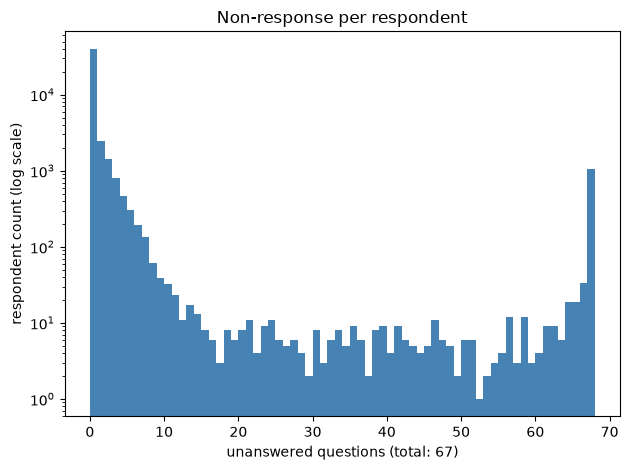

In [7]:
#Non-response count
qcols = [col for col in ling_data.columns if col.startswith('Q')]
n_missing = (ling_data[qcols]==0).sum(axis=1)
print("respondents:", len(ling_data), "questions:", len(qcols))
print(n_missing.describe())
fig, ax = plt.subplots()
ax.hist(n_missing, bins=range(0, len(qcols) + 2), log=True, color="steelblue")
ax.set_xlabel("unanswered questions (total: 67)")
ax.set_ylabel("respondent count (log scale)")
ax.set_title("Non-response per respondent")
fig.tight_layout()


We should drop the participants that have no answers at all.

In [8]:
n_missing.value_counts().sort_index()

0     40061
1      2489
2      1416
3       793
4       470
      ...  
63        6
64       19
65       19
66       33
67     1040
Name: count, Length: 68, dtype: int64

In [9]:
#answer code out of range?
for q in qcols:
    max_answer = len(questions[q]["answers"])
    out_of_range = ling_data[ling_data[q] > max_answer]
    if len(out_of_range) > 0:
        print(f"{q} has {len(out_of_range)} out-of-range answers")

There are no responses that are out of answer choice range.

In [10]:
# check coordinates
no_lat = ling_data['lat'].isna()
no_long = ling_data['long'].isna()
print(f"Missing lat: {no_lat.sum()}, Missing long: {no_long.sum()}")
print(f"Missing both: {(no_lat & no_long).sum()}")

Missing lat: 1020, Missing long: 1020
Missing both: 1020


1020 respondents missing coordinates. Are there patterns to missing data?

In [11]:
ling_data[no_lat].head(10)

,ID,CITY,STATE,ZIP,Q050,Q051,Q052,Q053,Q054,Q055,...,Q110,Q111,Q115,Q117,Q118,Q119,Q120,Q121,lat,long
23,25,weston,MA,02193,4,2,2,2,2,2,...,3,2,1,4,8,1,6,7,NaN,NaN
200,215,Brookline,MA,02146,7,3,2,2,2,2,...,8,2,1,4,7,1,2,1,NaN,NaN
313,331,Reston,VA,22090,1,2,3,2,2,2,...,8,2,1,1,0,3,2,3,NaN,NaN
347,365,Irvine,CA,92714,4,1,1,2,2,2,...,8,3,1,1,6,1,2,3,NaN,NaN
349,367,brookline,MA,02146,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,NaN,NaN
366,384,LosAngeles,CA,95411,7,2,2,2,2,2,...,8,2,1,1,7,1,1,1,NaN,NaN
444,465,Chicagoland,IL,60650,1,1,3,1,2,2,...,8,2,1,1,7,1,1,4,NaN,NaN
518,550,Atlanta,GA,30334,8,2,2,1,2,2,...,6,2,1,1,6,1,2,5,NaN,NaN
567,600,Belmont,MA,02178,7,2,2,2,2,2,...,8,2,4,4,7,1,3,6,NaN,NaN
607,644,Midlothian,VA,23114,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,NaN,NaN


In [12]:
ling_data[no_lat].tail(10)

,ID,CITY,STATE,ZIP,Q050,Q051,Q052,Q053,Q054,Q055,...,Q110,Q111,Q115,Q117,Q118,Q119,Q120,Q121,lat,long
46730,49310,Boston,MA,02164,4,2,2,2,2,2,...,8,2,1,3,7,1,2,6,NaN,NaN
46809,49390,Covington,GA,30208,9,2,1,1,2,2,...,9,3,1,1,6,1,2,3,NaN,NaN
46928,49510,AndrewsAFB,MD,20331,4,2,1,1,2,2,...,8,1,1,1,6,1,6,3,NaN,NaN
46958,49542,Lexington,KY,40103,1,2,2,2,2,2,...,8,2,1,1,7,1,2,6,NaN,NaN
46960,49544,Norfolk,VA,23013,9,1,3,2,3,2,...,6,2,2,1,8,1,2,3,NaN,NaN
47089,49676,Mumbai,NY,12462,4,2,2,2,2,2,...,9,2,1,1,7,2,2,3,NaN,NaN
47259,49849,Brookline,MA,02146,7,2,1,2,2,2,...,8,2,1,3,7,1,1,1,NaN,NaN
47375,49966,Newton,MA,02194,7,2,3,2,2,2,...,8,3,1,1,7,1,2,6,NaN,NaN
47384,49975,Placentia,CA,92670,4,1,3,2,2,2,...,8,2,1,1,6,1,2,4,NaN,NaN
47395,49986,Arlington,MA,02174,7,2,3,2,2,2,...,8,3,1,3,7,1,5,1,NaN,NaN


In [13]:
ling_data[no_lat].groupby('STATE').size().sort_values(ascending=False).head(10)

STATE
MA    230
CA    192
VA    118
FL    114
IL     51
NY     50
TX     45
GA     44
KS     18
MN     17
dtype: int64

In [14]:
ling_data[no_lat].groupby('CITY').size().sort_values(ascending=False).head(10)

CITY
Newton        39
Boston        34
Lexington     25
Chicago       23
Clearwater    22
Fullerton     21
Brookline     20
Arlington     20
Irvine        20
Reston        17
dtype: int64

Most of the missing coordinates are from the same state, and often seem to be grouped by city. 

In [15]:
def clean_data(df, max_nonresponse=66):
    qcols = [col for col in df.columns if col.startswith('Q')]
    df = df.dropna(subset=['lat', 'long'])
    
    n_missing = (df[qcols]==0).sum(axis=1)
    df = df[n_missing <= max_nonresponse]
    
    return df.reset_index(drop=True)

For the analyses, we need to onehot encode the responses.

In [16]:
def onehot_encode(ling_data, questions):
    '''One-hot encode the responses. Non-responses become zero'''
    qcols = [c for c in ling_data.columns if c.startswith("Q")]
    answers = pd.DataFrame({
        q: pd.Categorical(ling_data[q].where(ling_data[q]>0), categories=range(1, len(questions[q]["answers"]) + 1))
        for q in qcols
    })
    return pd.get_dummies(answers).astype(float)

In [17]:
cleaned_data = clean_data(ling_data)
X = onehot_encode(cleaned_data, questions)

In [18]:
X

,Q050_1,Q050_2,Q050_3,Q050_4,Q050_5,Q050_6,Q050_7,Q050_8,Q050_9,Q051_1,...,Q120_4,Q120_5,Q120_6,Q121_1,Q121_2,Q121_3,Q121_4,Q121_5,Q121_6,Q121_7
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45431,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
45432,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
45433,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
45434,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
